Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
INTERGENIC_TES_DISTANCES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\TE_Intergenic_With_Distances_NPC.bed"
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Expression_TE_DESeq_NPC.csv"
THRESHOLD_DISTANCE = 4000
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Clinical_Data_Rodrigues20.csv"

Histogram

     0       1       2                 3     4  5             6     7     8   \
0  chr1   81231   81691   TE_Tigger5_dup1  2382  +  TcMar-Tigger   DNA  chr1   
1  chr1  196882  196934  TE_MIR1_Amn_dup3   213  +           MIR  SINE  chr1   
2  chr1  197095  197166       TE_L2c_dup7   200  -            L2  LINE  chr1   
3  chr1  197312  197576     TE_AluSp_dup6  2050  +           Alu  SINE  chr1   
4  chr1  197790  198040     TE_MER33_dup2  1297  +   hAT-Charlie   DNA  chr1   

       9       10        11 12 13     14  
0   65418   71585     OR4F5  .  +   9647  
1  182695  184174  DDX11L17  .  +  12709  
2  185216  195411    WASH9P  .  -   1685  
3  182695  184174  DDX11L17  .  +  13139  
4  182695  184174  DDX11L17  .  +  13617  
     Start     End  Count
0      1.0   500.9   2558
1    500.9  1000.8   2363
2   1000.8  1500.7   1877
3   1500.7  2000.6   1547
4   2000.6  2500.5   1366
5   2500.5  3000.4   1198
6   3000.4  3500.3   1018
7   3500.3  4000.2    967
8   4000.2  4500.1    826
9

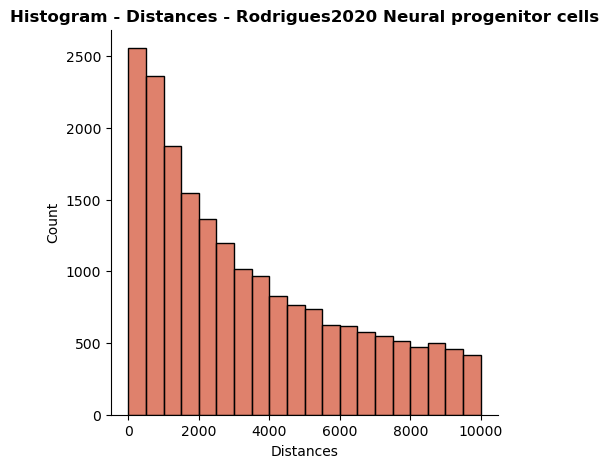

In [3]:
TEs_df = pd.read_csv(INTERGENIC_TES_DISTANCES, sep = '\t', header = None)
print(TEs_df.head())

TEs_df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']

def plot_histogram(df):
    fig, ax = plt.subplots(figsize = (5,5))

    final_df = df[df['Distances'] < 10000]

    sns.histplot(data = final_df, x = 'Distances', bins = 20, color = '#D5573B')

    ax.set_title('Histogram - Distances - Rodrigues2020 Neural progenitor cells', fontweight = 'bold', fontsize = 12)
    sns.despine()
    plt.plot()
    get_count(ax)

def get_count(ax): # Alternativamente podia utilizar o numpy.histogram
    patches = ax.patches # Uma patch é um objeto gráfico 2D que representa uma forma geométrica (ou seja é tipo os pontos e as barras)
    bin_count = []
    bin_edges = []

    for patch in patches: # Só há 20 barras, há uma que não vai ficar nas edges
        bin_count.append(patch.get_height()) # Também podia ter feito bin_count = [patch for patch in patches], mas assim é mais eficiente
        bin_edges.append(patch.get_x())

    bin_width = patch.get_width()
    bin_edges.append(patches[-1].get_x() + bin_width) # Para conseguir a última edge

    hist_df = pd.DataFrame( {
                'Start' : bin_edges[:-1],
                'End' : bin_edges[1:],
                'Count' : bin_count
    }
    )
    print(hist_df)

plot_histogram(TEs_df)


PCA Intergenics - Data

In [4]:
# Read files
expr_df = pd.read_csv(EXPRESSION_FILE)
clinical_df = pd.read_csv(CLINICAL_DATA, sep = ';')

# Merge to get intergenic
expr_df = expr_df.rename(columns = {'Unnamed: 0' : 'TE_Name'})
TEs_df = TEs_df[['TE_Name']]
expr_df = expr_df.merge(TEs_df, on = 'TE_Name', how = 'inner')

# Organize and extract expression file
TEs_names = expr_df['TE_Name']
counts = expr_df.iloc[:, 1:]

# Organize clinical data
clinical_df = clinical_df[['Sample_Name', 'Run', 'Condition']]
print(clinical_df)

# Make log2cpm
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)


# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

# PCA
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# Merge it all
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)]) # Os nomes das amostras ficam como index e as colunas são as componentes principais
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_df, on = 'Sample_Name', how = 'left')
pca_df.head()


     Sample_Name         Run Condition
0    NPC_WT_rep1  SRR8314922        WT
1    NPC_WT_rep1  SRR8314923        WT
2    NPC_WT_rep1  SRR8314924        WT
3   NPC_RTT_rep1  SRR8314928       RTT
4   NPC_RTT_rep1  SRR8314929       RTT
5   NPC_RTT_rep1  SRR8314930       RTT
6    Neu_WT_rep1  SRR8314934        WT
7    Neu_WT_rep1  SRR8314935        WT
8    Neu_WT_rep1  SRR8314936        WT
9   Neu_RTT_rep1  SRR8314940       RTT
10  Neu_RTT_rep1  SRR8314941       RTT
11  Neu_RTT_rep1  SRR8314942       RTT
12   NPC_WT_rep2  SRR8314952        WT
13   NPC_WT_rep2  SRR8314953        WT
14   NPC_WT_rep2  SRR8314954        WT
15  NPC_RTT_rep2  SRR8314958       RTT
16   Neu_WT_rep2  SRR8314962        WT
17   Neu_WT_rep2  SRR8314963        WT
18   Neu_WT_rep2  SRR8314964        WT
19  Neu_RTT_rep2  SRR8314968       RTT
20  Neu_RTT_rep2  SRR8314969       RTT
21  Neu_RTT_rep2  SRR8314970       RTT
22  NPC_RTT_rep3  SRR8314980       RTT
23   Neu_WT_rep3  SRR8314982        WT
24   Neu_WT_rep3  SRR8314

,Sample_Name,PC1,PC2,Run,Condition
0,NPC_RTT_rep1,116.706823,48.510593,SRR8314928,RTT
1,NPC_RTT_rep1,116.706823,48.510593,SRR8314929,RTT
2,NPC_RTT_rep1,116.706823,48.510593,SRR8314930,RTT
3,NPC_RTT_rep2,75.379330,-129.317585,SRR8314958,RTT
4,NPC_RTT_rep3,73.321009,92.341739,SRR8314980,RTT


PCA - Graph

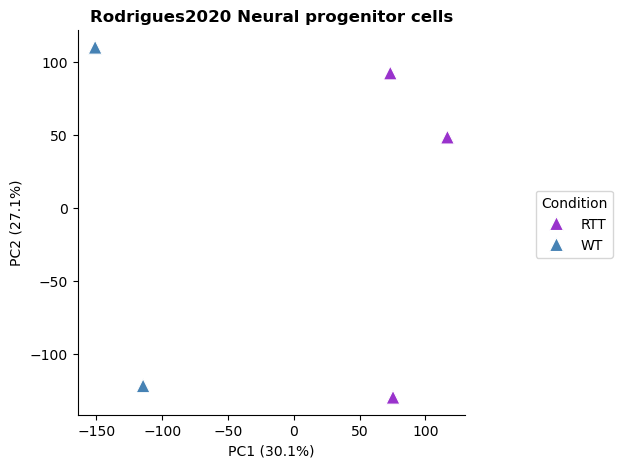

In [6]:
fig, ax = plt.subplots(figsize = (5 ,5))

palette_pca = {
    'RTT' : 'darkorchid',
    'WT' : 'steelblue'
}

sns.scatterplot(pca_df, x = 'PC1', y = 'PC2', hue = 'Condition', palette = palette_pca, s = 100, marker = '^')

# Labels
ax.set_title('Rodrigues2020 Neural progenitor cells', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()